# Applied Economics Software II — Week 8
## Machine Learning for Regression Problems
### Prepared by
**Eren Eskicioğlu**

[GitHub](https://github.com/MrESKK)

[Scikit-learn Documentation](https://scikit-learn.org/stable/)  

### Overview
This notebook applies machine learning models to regression problems. The analysis is organized into two main applications:

1. **Housing price prediction** using the Housing Prices dataset.
2. **Turkey GDP prediction** using macroeconomic indicators from the World Bank database.

The notebook follows the standard machine learning workflow: data loading, preprocessing, train-test split, model training, model evaluation, visualization, and model saving.


## 1. Packages
The following libraries are used for data manipulation, visualization, model training, model evaluation, and model saving.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Helper Function for Model Evaluation
This function calculates the main regression performance metrics used throughout the notebook.


In [2]:
def evaluate_regression_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("Model Evaluation Metrics:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R² Score: {r2}")

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


# Part I — Housing Price Prediction

## 3. Data
The first application uses a housing prices dataset from Kaggle. The target variable is `price`, and the remaining columns are used as explanatory variables.

> If the file is not already available in Colab, upload [`Housing.csv`](https://drive.google.com/file/d/1RbwiOED5JI1FywmvBF78_ih-xbiZyl8m/view?usp=sharing) to the `/content/` directory before running this section.


In [3]:
data = pd.read_csv("/content/Housing.csv")
data.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 4. Data Preprocessing
Categorical variables must be converted into numerical variables before they can be used in scikit-learn models. First, the binary `prefarea` variable is mapped manually. Then, remaining categorical variables are converted with one-hot encoding.


In [4]:
data["prefarea"] = data["prefarea"].map({"yes": 1, "no": 0})
data = pd.get_dummies(data, drop_first=True)
data.head()


,price,area,bedrooms,bathrooms,stories,parking,prefarea,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,True,False,False,False,True,False,False
1,12250000,8960,4,4,4,3,0,True,False,False,False,True,False,False
2,12250000,9960,3,2,2,2,1,True,False,True,False,False,True,False
3,12215000,7500,4,2,2,3,1,True,False,True,False,True,False,False
4,11410000,7420,4,1,2,2,0,True,True,True,False,True,False,False


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   prefarea                         545 non-null    int64
 7   mainroad_yes                     545 non-null    bool 
 8   guestroom_yes                    545 non-null    bool 
 9   basement_yes                     545 non-null    bool 
 10  hotwaterheating_yes              545 non-null    bool 
 11  airconditioning_yes              545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

## 5. Defining Features and Target Variable
`X` contains the independent variables, while `y` contains the dependent variable, which is house price.


In [6]:
X = data.drop("price", axis=1)
y = data["price"]

X.head()


,area,bedrooms,bathrooms,stories,parking,prefarea,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,True,False,False,False,True,False,False
1,8960,4,4,4,3,0,True,False,False,False,True,False,False
2,9960,3,2,2,2,1,True,False,True,False,False,True,False
3,7500,4,2,2,3,1,True,False,True,False,True,False,False
4,7420,4,1,2,2,0,True,True,True,False,True,False,False


In [ ]:
y.head()


## 6. Train-Test Split
The data is divided into training and test sets. The model learns from the training set and is evaluated on the test set.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Number of training samples:", len(X_train))
print("Number of test samples:", len(X_test))


Number of training samples: 436
Number of test samples: 109


## 7. Linear Regression
Linear Regression is used as a baseline regression model. It assumes a linear relationship between the explanatory variables and the target variable.


In [8]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
lr_results = evaluate_regression_model(y_test, y_pred_lr)


Model Evaluation Metrics:
Mean Absolute Error (MAE): 970043.403920164
Mean Squared Error (MSE): 1754318687330.6643
Root Mean Squared Error (RMSE): 1324506.9600914388
R² Score: 0.6529242642153184


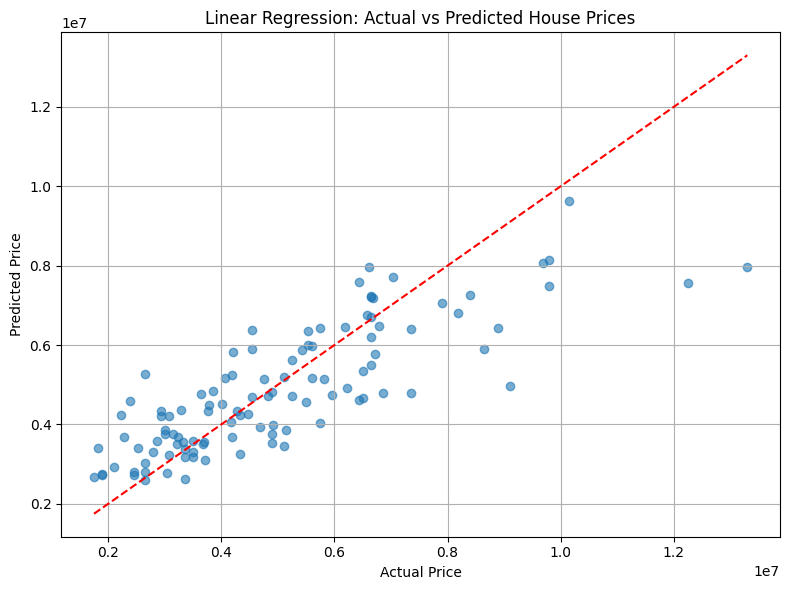

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted House Prices")
plt.grid(True)
plt.tight_layout()
plt.show()


## 8. Decision Tree Regressor
A Decision Tree Regressor divides the data into smaller groups by creating rule-based splits. For example, it may split houses according to size, number of rooms, air conditioning, basement availability, or preferred area.


In [10]:
model_dtr = DecisionTreeRegressor(max_depth=10, random_state=0)
model_dtr.fit(X_train, y_train)

y_pred_dtr = model_dtr.predict(X_test)
dtr_results = evaluate_regression_model(y_test, y_pred_dtr)


Model Evaluation Metrics:
Mean Absolute Error (MAE): 1235839.373088685
Mean Squared Error (MSE): 2778298026225.9673
Root Mean Squared Error (RMSE): 1666822.7338940296
R² Score: 0.45033941743575956


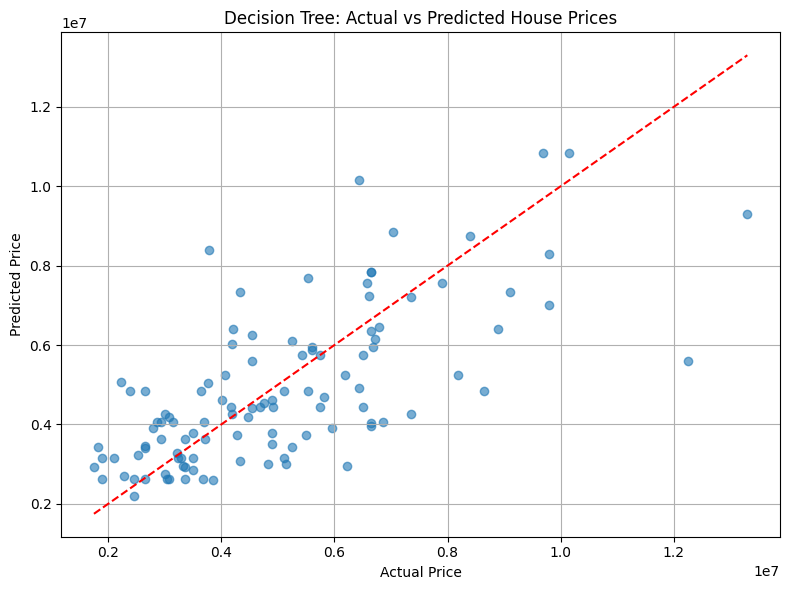

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dtr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted House Prices")
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Random Forest Regressor
Random Forest is an ensemble learning method. It builds many decision trees and combines their predictions. This usually reduces overfitting compared with a single decision tree.


In [12]:
model_rfr = RandomForestRegressor(n_estimators=1000, max_depth=6, random_state=0)
model_rfr.fit(X_train, y_train)

y_pred_rfr = model_rfr.predict(X_test)
rfr_results = evaluate_regression_model(y_test, y_pred_rfr)


Model Evaluation Metrics:
Mean Absolute Error (MAE): 1050090.5832792986
Mean Squared Error (MSE): 2015035286757.071
Root Mean Squared Error (RMSE): 1419519.385833484
R² Score: 0.6013438950208901


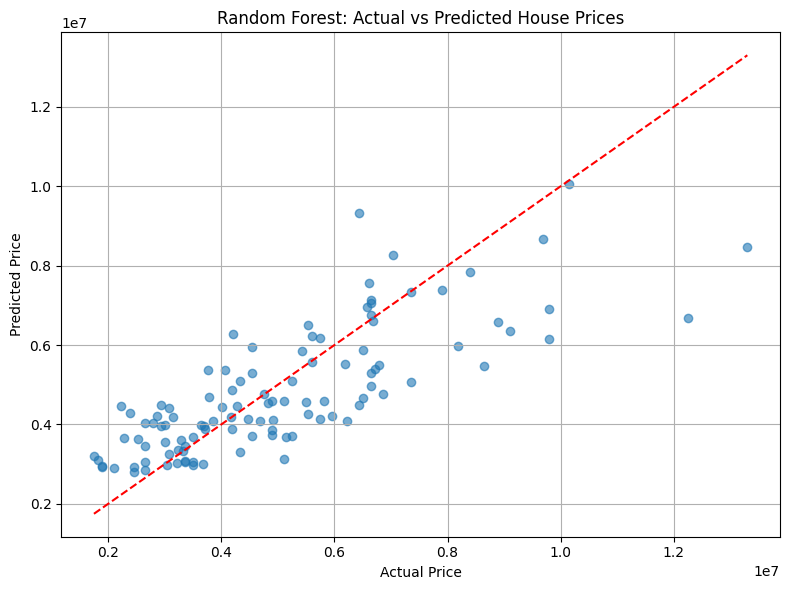

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rfr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted House Prices")
plt.grid(True)
plt.tight_layout()
plt.show()


## 10. K-Nearest Neighbors Regressor
Since the target variable is continuous, a regression model must be used. Therefore, `KNeighborsRegressor` is used instead of `NearestCentroid`, which is designed for classification problems.


In [14]:
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)
knn_results = evaluate_regression_model(y_test, y_pred_knn)


Model Evaluation Metrics:
Mean Absolute Error (MAE): 1296547.7064220184
Mean Squared Error (MSE): 3213839804128.4404
Root Mean Squared Error (RMSE): 1792718.5512869665
R² Score: 0.36417150272211063


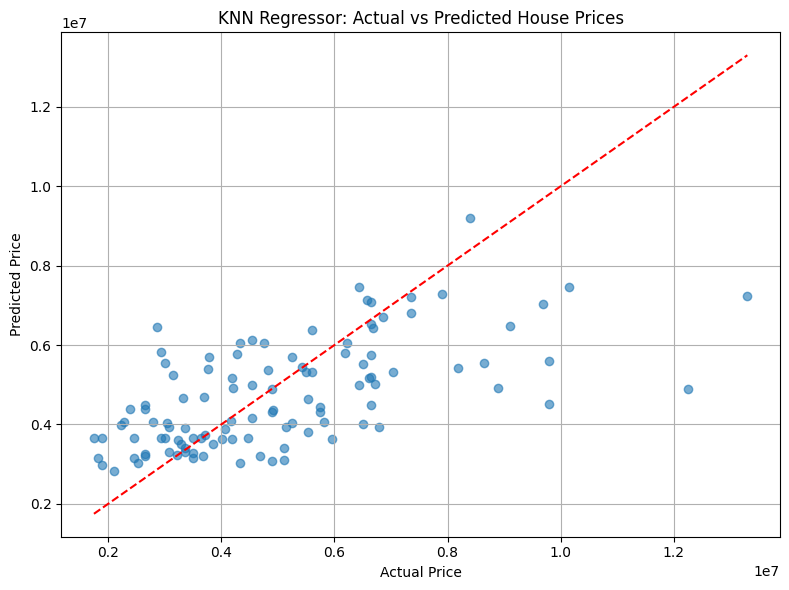

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("KNN Regressor: Actual vs Predicted House Prices")
plt.grid(True)
plt.tight_layout()
plt.show()


## 11. Housing Model Comparison
The following table compares the models according to MAE, RMSE, and R² score.


In [16]:
housing_results = pd.DataFrame([
    {"Model": "Linear Regression", **lr_results},
    {"Model": "Decision Tree", **dtr_results},
    {"Model": "Random Forest", **rfr_results},
    {"Model": "KNN Regressor", **knn_results}
])

housing_results.sort_values(by="RMSE")


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
2,Random Forest,1.050091e+06,2.015035e+12,1.419519e+06,0.601344
1,Decision Tree,1.235839e+06,2.778298e+12,1.666823e+06,0.450339
3,KNN Regressor,1.296548e+06,3.213840e+12,1.792719e+06,0.364172


# Part II — Alternative Dataset: California Housing

This section uses the built-in California Housing dataset from scikit-learn. It is useful because it can be loaded directly without uploading an external CSV file.


In [17]:
from sklearn import datasets

housing = datasets.fetch_california_housing()

x = housing.data
y_alt = housing.target

print("Dataset column names:", housing.feature_names)
print("Number of rows:", len(x))
print("Number of columns:", len(housing.feature_names))


Dataset column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Number of rows: 20640
Number of columns: 8


In [18]:
x_train, x_test, y_train_alt, y_test_alt = train_test_split(
    x,
    y_alt,
    test_size=0.2,
    random_state=432
)

print("Number of training samples:", len(x_train))
print("Number of test samples:", len(x_test))


Number of training samples: 16512
Number of test samples: 4128


## 12. Comparing Ensemble Models on California Housing
Different machine learning models are trained and compared using the same train-test split.


In [19]:
models_alt = {
    "Linear Regression": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

for name, model in models_alt.items():
    model.fit(x_train, y_train_alt)
    y_pred_alt = model.predict(x_test)
    r2 = r2_score(y_test_alt, y_pred_alt)
    print("Model:", name)
    print("R² Score:", r2)
    print("-------------")


Model: Linear Regression
R² Score: 0.6080229586580355
-------------
Model: Gradient Boosting
R² Score: 0.7878126561044645
-------------
Model: Random Forest
R² Score: 0.8138275770938629
-------------
Model: HistGradientBoosting
R² Score: 0.8334847395040117
-------------


## 13. Hyperparameter Testing
The following cells test different values for the number of boosting iterations and learning rates in `HistGradientBoostingRegressor`.


In [20]:
for i in [100, 200, 300, 400, 500]:
    model = HistGradientBoostingRegressor(max_iter=i, random_state=42)
    model.fit(x_train, y_train_alt)
    y_pred_alt = model.predict(x_test)
    r2 = r2_score(y_test_alt, y_pred_alt)

    print("Number of iterations:", i)
    print("R² Score:", r2)
    print("-------------")


Number of iterations: 100
R² Score: 0.8334847395040117
-------------
Number of iterations: 200
R² Score: 0.841033342436884
-------------
Number of iterations: 300
R² Score: 0.841033342436884
-------------
Number of iterations: 400
R² Score: 0.841033342436884
-------------
Number of iterations: 500
R² Score: 0.841033342436884
-------------


In [21]:
for learning_rate in [0.1, 0.05, 0.001]:
    for max_iter in [200, 300, 400]:
        model = HistGradientBoostingRegressor(
            max_iter=max_iter,
            learning_rate=learning_rate,
            random_state=42
        )
        model.fit(x_train, y_train_alt)
        y_pred_alt = model.predict(x_test)
        r2 = r2_score(y_test_alt, y_pred_alt)

        print("Number of iterations:", max_iter)
        print("Learning rate:", learning_rate)
        print("R² Score:", r2)
        print("-------------")


Number of iterations: 200
Learning rate: 0.1
R² Score: 0.841033342436884
-------------
Number of iterations: 300
Learning rate: 0.1
R² Score: 0.841033342436884
-------------
Number of iterations: 400
Learning rate: 0.1
R² Score: 0.841033342436884
-------------
Number of iterations: 200
Learning rate: 0.05
R² Score: 0.8361471443508632
-------------
Number of iterations: 300
Learning rate: 0.05
R² Score: 0.8429054258611558
-------------
Number of iterations: 400
Learning rate: 0.05
R² Score: 0.8453617358218639
-------------
Number of iterations: 200
Learning rate: 0.001
R² Score: 0.21797470591898227
-------------
Number of iterations: 300
Learning rate: 0.001
R² Score: 0.30061612589560316
-------------
Number of iterations: 400
Learning rate: 0.001
R² Score: 0.3692368807620724
-------------


## 14. Model Saving
After choosing a model, it can be saved with `joblib`. This allows the trained model to be loaded and used later without retraining.


In [22]:
final_model = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    random_state=42
)

final_model.fit(x_train, y_train_alt)
joblib.dump(final_model, "my_model.joblib")

saved_model = joblib.load("my_model.joblib")
y_pred_saved = saved_model.predict(x_test)
r2_saved = r2_score(y_test_alt, y_pred_saved)

print("Saved model R² score:", r2_saved)


Saved model R² score: 0.8453617358218639


# Part III — Machine Learning Models for Predicting Turkey's GDP Using Macroeconomic Indicators

## 15. Economic Model
In this part, Turkey's GDP is predicted by using macroeconomic variables from the World Bank database.

The basic national income identity is:

$$
Y = C + I + G + (X - M)
$$

Where:

- $Y$ = GDP
- $C$ = Consumption
- $I$ = Investment
- $G$ = Government Expenditure
- $X$ = Exports
- $M$ = Imports

Net exports are calculated as:

$$
NX = X - M
$$

Therefore, the machine learning model uses consumption, investment, government expenditure, exports, imports, and net exports to estimate GDP.


## 16. Installing and Importing World Bank Data Package
`wbdata` is used to collect macroeconomic data from the World Bank database.


In [23]:
!pip install wbdata


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.6
    Uninstalling cachetools-6.2.6:
      Successfully uninstalled cachetools-6.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [1]:
import wbdata

indicators = {
    "NY.GDP.MKTP.CD": "GDP",
    "NE.CON.PRVT.CD": "Consumption",
    "NE.GDI.TOTL.CD": "Investment",
    "NE.CON.GOVT.CD": "Government_Expenditure",
    "NE.EXP.GNFS.CD": "Exports",
    "NE.IMP.GNFS.CD": "Imports"
}


## 17. Collecting and Preparing Turkey Data
The data is collected for Turkey, cleaned, sorted by year, and prepared for model training.


In [2]:
df = wbdata.get_dataframe(indicators, country="TUR")

df = df.reset_index()
df = df.rename(columns={"date": "Year"})
df["Year"] = df["Year"].astype(int)
df = df.sort_values("Year")
df = df.dropna()

df.head()


,Year,GDP,Consumption,Investment,Government_Expenditure,Exports,Imports
65,1960,7.566667e+09,4.266667e+09,7.555556e+08,6.333333e+08,1.555556e+08,2.777778e+08
64,1961,7.988889e+09,4.500000e+09,8.000000e+08,7.444444e+08,4.111111e+08,5.444444e+08
63,1962,8.922222e+09,4.944444e+09,9.555556e+08,8.777778e+08,5.000000e+08,7.111111e+08
62,1963,1.035556e+10,5.688889e+09,1.211111e+09,9.777778e+08,4.333333e+08,7.222222e+08
61,1964,1.117778e+10,5.988889e+09,1.222222e+09,1.100000e+09,5.000000e+08,6.111111e+08


In [3]:
df.tail()


,Year,GDP,Consumption,Investment,Government_Expenditure,Exports,Imports
5,2020,7.336282e+11,3.941329e+11,2.505638e+11,1.102790e+11,2.108448e+11,2.321922e+11
4,2021,8.399387e+11,4.374391e+11,2.887385e+11,1.095751e+11,2.944290e+11,2.902430e+11
3,2022,9.260975e+11,4.926505e+11,3.574934e+11,1.094398e+11,3.532248e+11,3.867111e+11
2,2023,1.141243e+12,6.166328e+11,3.947362e+11,1.510556e+11,3.642116e+11,3.853933e+11
1,2024,1.359124e+12,7.376650e+11,4.176744e+11,1.964771e+11,3.746863e+11,3.673791e+11


In [4]:
df["Net_Exports"] = df["Exports"] - df["Imports"]
df.head()


,Year,GDP,Consumption,Investment,Government_Expenditure,Exports,Imports,Net_Exports
65,1960,7.566667e+09,4.266667e+09,7.555556e+08,6.333333e+08,1.555556e+08,2.777778e+08,-1.222222e+08
64,1961,7.988889e+09,4.500000e+09,8.000000e+08,7.444444e+08,4.111111e+08,5.444444e+08,-1.333333e+08
63,1962,8.922222e+09,4.944444e+09,9.555556e+08,8.777778e+08,5.000000e+08,7.111111e+08,-2.111111e+08
62,1963,1.035556e+10,5.688889e+09,1.211111e+09,9.777778e+08,4.333333e+08,7.222222e+08,-2.888889e+08
61,1964,1.117778e+10,5.988889e+09,1.222222e+09,1.100000e+09,5.000000e+08,6.111111e+08,-1.111111e+08


## 18. Defining the Macroeconomic Features
The explanatory variables are selected according to the national income identity.


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_gdp = df[[
    "Consumption",
    "Investment",
    "Government_Expenditure",
    "Exports",
    "Imports",
    "Net_Exports"
]]

y_gdp = df["GDP"]

X_train_gdp, X_test_gdp, y_train_gdp, y_test_gdp = train_test_split(
    X_gdp,
    y_gdp,
    test_size=0.2,
    random_state=42
)


## 19. Training GDP Prediction Models
Several regression algorithms are trained and compared using the same macroeconomic dataset.


In [10]:
models_gdp = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models_gdp.items():
    model.fit(X_train_gdp, y_train_gdp)
    y_pred_gdp = model.predict(X_test_gdp)

    r2 = r2_score(y_test_gdp, y_pred_gdp)
    mae = mean_absolute_error(y_test_gdp, y_pred_gdp)
    rmse = np.sqrt(mean_squared_error(y_test_gdp, y_pred_gdp))

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)
results_df


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.999908,3.423507e+09,4.137612e+09
1,Decision Tree,0.972822,4.047577e+10,7.105578e+10
2,Random Forest,0.954702,3.701371e+10,9.173359e+10
3,Gradient Boosting,0.977407,3.156786e+10,6.478594e+10
4,KNN,0.927521,4.663964e+10,1.160370e+11


In [11]:
results_df.sort_values(by="RMSE")


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.999908,3.423507e+09,4.137612e+09
3,Gradient Boosting,0.977407,3.156786e+10,6.478594e+10
1,Decision Tree,0.972822,4.047577e+10,7.105578e+10
2,Random Forest,0.954702,3.701371e+10,9.173359e+10
4,KNN,0.927521,4.663964e+10,1.160370e+11


In [12]:
best_model = results_df.sort_values(by="RMSE").iloc[0]

print("Best Model:")
print(best_model)


Best Model:
Model       Linear Regression
R2 Score             0.999908
MAE         3423506599.510146
RMSE        4137612354.466747
Name: 0, dtype: object


## 20. Visual Model Comparison
The following graphs compare model performance according to RMSE and R² score.


## 3. RMSE Comparison of Different Models (GDP Prediction)

In this section, we compare the performance of five different machine learning models used for GDP prediction by using the RMSE (Root Mean Squared Error) metric.

RMSE measures the average magnitude of prediction errors between predicted and actual values. A lower RMSE value indicates that the model predictions are closer to the real values and therefore the model performs better.

### About the Graph:
- **X-axis (Models):** Represents the machine learning models used in the analysis.
- **Y-axis (RMSE):** Represents the RMSE values of each model.
- Lower bars indicate better prediction performance.

### Interpretation of Results:
- [**Linear Regression**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) achieved the lowest RMSE value, indicating the best performance for GDP prediction in this dataset.
- [**Decision Tree**](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) and [**Gradient Boosting**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) models showed moderate performance with higher RMSE values compared to Linear Regression.
- [**Random Forest**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) produced a relatively higher error rate, suggesting that the model may not capture the relationship effectively for this dataset.
- [**K-Nearest Neighbors Regressor**](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) had the highest RMSE value, indicating the weakest prediction performance among all models.

Overall, this graph provides a visual comparison of model performances and helps identify the most suitable model for GDP prediction.

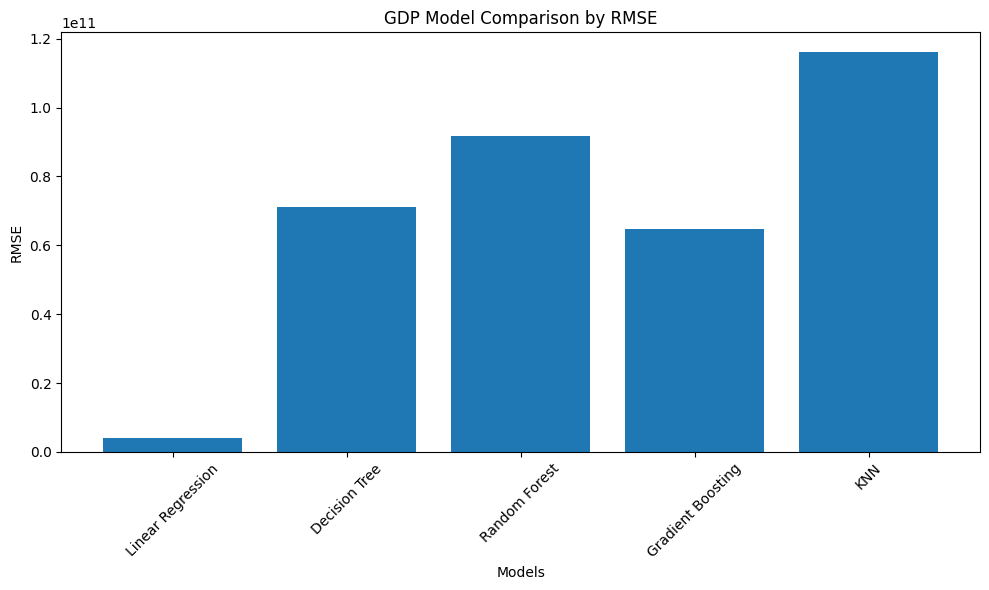

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45)
plt.title("GDP Model Comparison by RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


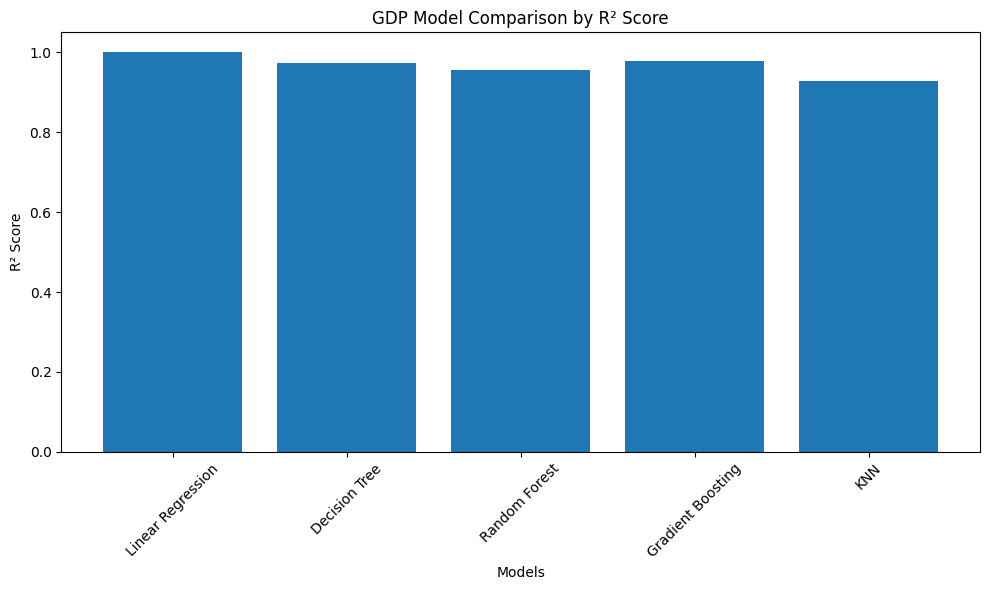

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.title("GDP Model Comparison by R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.tight_layout()
plt.show()


## 21. Conclusion
This notebook demonstrated how different machine learning models can be used for regression problems. In the housing price application, the models were compared according to standard regression metrics such as MAE, RMSE, and R² score. In the macroeconomic application, Turkey's GDP was predicted using variables derived from the national income identity.

Since GDP is theoretically connected to consumption, investment, government expenditure, exports, and imports through a linear macroeconomic identity, Linear Regression may perform better than more complex machine learning algorithms in this specific application. However, model performance should always be interpreted together with the size, quality, and theoretical structure of the dataset.
